100%|██████████| 170M/170M [00:03<00:00, 43.5MB/s]


Using Colab cache for faster access to the 'wikiart' dataset.


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:06<00:00, 86.3MB/s]


Step: 0 Loss: 14462996.0
Step: 50 Loss: 851155.9375
Step: 100 Loss: 408649.0
Step: 150 Loss: 271485.03125
Step: 200 Loss: 207712.75
Step: 250 Loss: 172234.109375


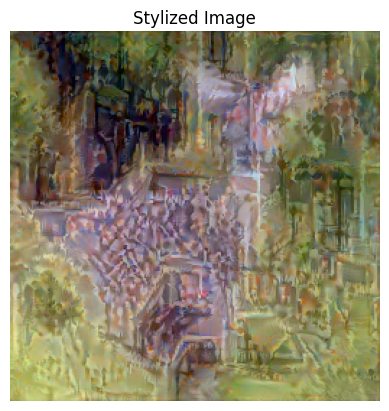

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import matplotlib.pyplot as plt
from PIL import Image
import kagglehub
import os
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -------------------------------------------------
# 1. Load Content Image from CIFAR-10
# -------------------------------------------------

transform_cifar = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.ToTensor()
])

cifar = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform_cifar
)

content_img, _ = cifar[random.randint(0,5000)]
content_img = content_img.unsqueeze(0).to(device)

# -------------------------------------------------
# 2. Download WikiArt Dataset (Style Image)
# -------------------------------------------------

path = kagglehub.dataset_download("steubk/wikiart")

style_images = []

for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith(".jpg") or file.endswith(".png"):
            style_images.append(os.path.join(root,file))

style_path = random.choice(style_images)

loader = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.ToTensor()
])

style_img = loader(Image.open(style_path).convert("RGB")).unsqueeze(0).to(device)

# -------------------------------------------------
# 3. Load Pretrained VGG19
# -------------------------------------------------

vgg = models.vgg19(pretrained=True).features.to(device).eval()

for param in vgg.parameters():
    param.requires_grad = False

# -------------------------------------------------
# 4. Feature Extraction
# -------------------------------------------------

def get_features(image, model):

    layers = {
        '0':'conv1_1',
        '5':'conv2_1',
        '10':'conv3_1',
        '19':'conv4_1',
        '21':'conv4_2',
        '28':'conv5_1'
    }

    features = {}
    x = image

    for name, layer in model._modules.items():
        x = layer(x)

        if name in layers:
            features[layers[name]] = x

    return features

content_features = get_features(content_img, vgg)
style_features = get_features(style_img, vgg)

# -------------------------------------------------
# 5. Gram Matrix (Style Representation)
# -------------------------------------------------

def gram_matrix(tensor):

    b,c,h,w = tensor.size()

    tensor = tensor.view(c, h*w)

    gram = torch.mm(tensor, tensor.t())

    return gram

style_grams = {layer: gram_matrix(style_features[layer]) for layer in style_features}

# -------------------------------------------------
# 6. Generated Image
# -------------------------------------------------

generated = content_img.clone().requires_grad_(True)

# -------------------------------------------------
# 7. Loss Weights
# -------------------------------------------------

style_weight = 1e6
content_weight = 1

optimizer = optim.Adam([generated], lr=0.003)

# -------------------------------------------------
# 8. Optimization Loop
# -------------------------------------------------

steps = 300

for step in range(steps):

    gen_features = get_features(generated, vgg)

    content_loss = torch.mean(
        (gen_features['conv4_2'] - content_features['conv4_2'])**2
    )

    style_loss = 0

    for layer in style_grams:

        gen_feature = gen_features[layer]
        gen_gram = gram_matrix(gen_feature)

        style_gram = style_grams[layer]

        _,c,h,w = gen_feature.shape

        layer_style_loss = torch.mean((gen_gram-style_gram)**2)

        style_loss += layer_style_loss/(c*h*w)

    total_loss = content_weight*content_loss + style_weight*style_loss

    optimizer.zero_grad()
    total_loss.backward()
    optimizer.step()

    if step % 50 == 0:
        print("Step:",step,"Loss:",total_loss.item())

# -------------------------------------------------
# 9. Show Output
# -------------------------------------------------

output = generated.cpu().clone().detach().squeeze(0)

plt.imshow(output.permute(1,2,0))
plt.axis("off")
plt.title("Stylized Image")
plt.show()